# FIT5196 Assessment 1 - Exploratory Data Analysis

**Group:** Group018


## 0. Configuration and data loading

Load the six standardised CSVs from `outputs/`. Keep analysis columns in memory
and save charts in `eda_figures/`. Paths are relative to the repository root.


In [1]:
from pathlib import Path

# Group name and folders
GROUP_ID = "Group018"
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = Path("eda_figures")

# Plot settings
HISTOGRAM_BINS = 40
TOP_PRODUCT_COUNT = 10
CURRENCY_TOLERANCE = 0.01
WEEK_FREQUENCY = "W-SUN"  # Monday to Sunday

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Analysing {GROUP_ID}.")
print(f"Reading standardised files from: {OUTPUT_DIR}")
print(f"Saving assessed figures to: {FIGURE_DIR}")


Analysing Group018.
Reading standardised files from: outputs
Saving assessed figures to: eda_figures


### 0.1 Environment and presentation

pandas is used for the analysis and matplotlib for the charts.


In [2]:
import hashlib
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, MaxNLocator

try:
    from IPython.display import Markdown, display
except ImportError:
    def Markdown(value):
        """Keep narrative output readable when IPython is unavailable."""
        return value

    def display(value):
        """Print a readable fallback when IPython display is unavailable."""
        if isinstance(value, pd.DataFrame):
            print(value.to_string(index=False))
        else:
            print(value)

print(f"Python version: {platform.python_version()}")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")

# Use a consistent, readable style across all assessed figures.
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

PRIMARY_COLOUR = "#306B83"
SECONDARY_COLOUR = "#A35E26"
NEUTRAL_COLOUR = "#58616C"


Python version: 3.12.13
pandas version: 2.2.3
NumPy version: 2.3.5
matplotlib version: 3.10.8


In [3]:
# Read identifiers as strings so leading zeros cannot be lost.
string_columns = {
    "orders": ["order_id", "source_system_record_id", "customer_id"],
    "order_items": ["order_item_id", "order_id", "product_id"],
    "customers": ["customer_id", "home_postcode"],
    "deliveries": ["delivery_id", "order_id"],
    "products": ["product_id", "product_sku", "supplier_id"],
    "product_reviews": [
        "review_id", "order_id", "order_item_id", "product_id", "customer_id",
    ],
}

tables = {}
input_file_hashes = {}
load_rows = []

for table_name, columns in string_columns.items():
    file_path = OUTPUT_DIR / f"{GROUP_ID}_{table_name}_standardised.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"Required standardised file is missing: {file_path}")

    input_file_hashes[table_name] = hashlib.sha256(file_path.read_bytes()).hexdigest()
    table = pd.read_csv(
        file_path,
        keep_default_na=False,
        dtype={column: str for column in columns},
    )
    tables[table_name] = table
    load_rows.append({
        "table": table_name,
        "rows": len(table),
        "columns": len(table.columns),
    })

orders = tables["orders"]
order_items = tables["order_items"]
customers = tables["customers"]
deliveries = tables["deliveries"]
products = tables["products"]
product_reviews = tables["product_reviews"]

load_summary = pd.DataFrame(load_rows)
display(load_summary)
print("The literal string NaN is preserved in every loaded CSV.")


,table,rows,columns
0,orders,5000,23
1,order_items,15618,6
2,customers,500,20
3,deliveries,5000,20
4,products,1000,21
5,product_reviews,7000,21


The literal string NaN is preserved in every loaded CSV.


### 0.2 Data checks

Check primary keys, currency and numeric fields before analysis.
These checks are separate from the Task 4 validation register.


In [4]:
eda_check_rows = []

def record_eda_check(check_id, description, passed, observed):
    """Record one analysis check and stop if its assumption fails."""
    eda_check_rows.append({
        "check_id": check_id,
        "description": description,
        "status": "PASS" if passed else "FAIL",
        "observed": observed,
    })
    if not passed:
        display(pd.DataFrame(eda_check_rows[-1:]))
        raise ValueError(f"{check_id} failed. Inspect the data before continuing.")

primary_keys = {
    "orders": "order_id", "order_items": "order_item_id",
    "customers": "customer_id", "deliveries": "delivery_id",
    "products": "product_id", "product_reviews": "review_id",
}

for table_name, primary_key in primary_keys.items():
    table = tables[table_name]
    missing_keys = int(
        table[primary_key].isna().sum()
        + table[primary_key].isin(["", "NaN"]).sum()
    )
    duplicate_keys = int(table[primary_key].duplicated(keep=False).sum())
    record_eda_check(
        f"EDA-PK-{table_name}", "Non-empty table with complete, unique primary keys",
        len(table) > 0 and missing_keys == 0 and duplicate_keys == 0,
        f"{len(table):,} rows; {missing_keys} missing and {duplicate_keys} duplicate keys",
    )

# The titles and denominators below describe completed orders in AUD.
record_eda_check(
    "EDA-SCOPE-01", "All analysed orders are completed AUD orders",
    orders["order_status"].eq("Completed").all() and orders["currency"].eq("AUD").all(),
    f"Statuses: {orders['order_status'].value_counts().to_dict()}; "
    f"currencies: {orders['currency'].value_counts().to_dict()}",
)

for table_name, fields in {
    "orders": ["order_total"],
    "order_items": ["line_revenue", "quantity"],
}.items():
    for field in fields:
        values = tables[table_name][field]
        is_numeric = pd.api.types.is_numeric_dtype(values)
        valid_values = is_numeric and np.isfinite(values).all() and values.gt(0).all()
        record_eda_check(
            f"EDA-NUMERIC-{table_name}-{field}", "Finite positive numeric analysis field",
            valid_values, f"{len(values):,} values; dtype {values.dtype}",
        )

record_eda_check(
    "EDA-FK-items-orders", "Every item belongs to an analysed order",
    order_items["order_id"].isin(orders["order_id"]).all(),
    f"{int((~order_items['order_id'].isin(orders['order_id'])).sum())} unmatched item rows",
)
display(pd.DataFrame(eda_check_rows))


,check_id,description,status,observed
0,EDA-PK-orders,"Non-empty table with complete, unique primary ...",PASS,"5,000 rows; 0 missing and 0 duplicate keys"
1,EDA-PK-order_items,"Non-empty table with complete, unique primary ...",PASS,"15,618 rows; 0 missing and 0 duplicate keys"
2,EDA-PK-customers,"Non-empty table with complete, unique primary ...",PASS,500 rows; 0 missing and 0 duplicate keys
3,EDA-PK-deliveries,"Non-empty table with complete, unique primary ...",PASS,"5,000 rows; 0 missing and 0 duplicate keys"
4,EDA-PK-products,"Non-empty table with complete, unique primary ...",PASS,"1,000 rows; 0 missing and 0 duplicate keys"
5,EDA-PK-product_reviews,"Non-empty table with complete, unique primary ...",PASS,"7,000 rows; 0 missing and 0 duplicate keys"
6,EDA-SCOPE-01,All analysed orders are completed AUD orders,PASS,Statuses: {'Completed': 5000}; currencies: {'A...
7,EDA-NUMERIC-orders-order_total,Finite positive numeric analysis field,PASS,"5,000 values; dtype float64"
8,EDA-NUMERIC-order_items-line_revenue,Finite positive numeric analysis field,PASS,"15,618 values; dtype float64"
9,EDA-NUMERIC-order_items-quantity,Finite positive numeric analysis field,PASS,"15,618 values; dtype float64"


## 1. Context and data-preparation assurance

The allocated historical data describe orders, customers, products, completed
deliveries and product reviews for a Melbourne technology retailer. The analysis
examines order totals, product revenue and weekly order counts within this extract.

Relevant transformation decisions:

| Transformation decision | Existing mapping evidence |
|---|---|
| Normalise overlapping orders before comparison, retain one canonical order and record conflicting values without automatic source precedence. | `MAP-orders-01` |
| Standardise source-specific order timestamps before temporal analysis. | `MAP-orders-04` |
| Round quantity times unit price to obtain each line's revenue; sum those rounded lines to obtain order price. | `MAP-order_items-06`, `MAP-orders-10` |
| Apply the coupon discount and add delivery charges to calculate order total. GST is already included and is not added a second time. | `MAP-orders-13`, `MAP-orders-14`, `MAP-orders-15` |

The solution notebook records **61 Task 4 checks passing and zero failures**.
The results below come from its saved validation summary and earlier checks;
they are not rerun in this notebook.

| Recorded validation result | Existing validation evidence |
|---|---|
| Orders, items and products contain 23/23, 6/6 and 21/21 expected columns in the required order. | `VAL-SCHEMA-orders`, `VAL-SCHEMA-order_items`, `VAL-SCHEMA-products` |
| Orders, items and products have no missing or duplicated primary keys. | `VAL-PK-orders`, `VAL-PK-order_items`, `VAL-PK-products` |
| Item product references have no orphan keys. | `VAL-FK-order_items-product_id` |
| Reconciliation records zero unresolved order-field conflicts. | `VAL-FLOW-order-conflicts` |
| No order price, tax or total comparison exceeds the published AUD 0.01 tolerance. | `VAL-ARITH-order_price`, `VAL-ARITH-tax_amount`, `VAL-ARITH-order_total` |
| Order-before-dispatch, dispatch-before-delivery and review-after-order checks passed. | `VAL-TIME-order-before-dispatch`, `VAL-TIME-dispatch-before-delivery`, `VAL-TIME-review-after-order` |

The `EDA-...` checks below verify the loaded data and analysis joins.


## 2. Assessed EDA visualisations

### Figure 1: Distribution of completed-order totals

**Question:** What is a typical completed-order total, and how much variation
is hidden by the average?  
**Category:** Univariate distribution.  
**Observation unit:** One canonical completed order, identified by `order_id`.  
**Denominator:** All completed AUD orders in the extract. The exact count is
displayed below; no high-value order is excluded.  
**Tables and join keys:** `orders.order_total`; no join.  
**Chart choice:** A histogram shows the frequency distribution, with separate
mean and median lines. The full value range is shown.  
**Measure:** AUD order total after coupon discount, including delivery charges
and the already included GST component.


In [5]:
# Calculate the distribution at one-row-per-order grain.
order_totals = orders["order_total"]
order_count = len(order_totals)
mean_order_total = order_totals.mean()
median_order_total = order_totals.median()
lower_quartile = order_totals.quantile(0.25)
upper_quartile = order_totals.quantile(0.75)
interquartile_range = upper_quartile - lower_quartile
upper_tail_fence = upper_quartile + 1.5 * interquartile_range
upper_tail_count = int(order_totals.gt(upper_tail_fence).sum())
upper_tail_percentage = 100 * upper_tail_count / order_count
mean_median_gap_percentage = 100 * (mean_order_total / median_order_total - 1)

order_summary = pd.DataFrame([
    {"statistic": "Completed orders", "value": f"{order_count:,}"},
    {"statistic": "Mean order total (AUD)", "value": f"{mean_order_total:,.2f}"},
    {"statistic": "Median order total (AUD)", "value": f"{median_order_total:,.2f}"},
    {"statistic": "25th percentile (AUD)", "value": f"{lower_quartile:,.2f}"},
    {"statistic": "75th percentile (AUD)", "value": f"{upper_quartile:,.2f}"},
    {"statistic": "Minimum (AUD)", "value": f"{order_totals.min():,.2f}"},
    {"statistic": "Maximum (AUD)", "value": f"{order_totals.max():,.2f}"},
    {"statistic": "Upper 1.5-IQR fence (AUD)", "value": f"{upper_tail_fence:,.2f}"},
    {"statistic": "Orders above the fence", "value": f"{upper_tail_count:,} ({upper_tail_percentage:.2f}%)"},
])
display(order_summary)


,statistic,value
0,Completed orders,"5,000"
1,Mean order total (AUD),"2,804.05"
2,Median order total (AUD),"2,371.01"
3,25th percentile (AUD),"1,333.65"
4,75th percentile (AUD),"3,829.78"
5,Minimum (AUD),23.37
6,Maximum (AUD),"18,565.28"
7,Upper 1.5-IQR fence (AUD),"7,573.98"
8,Orders above the fence,150 (3.00%)


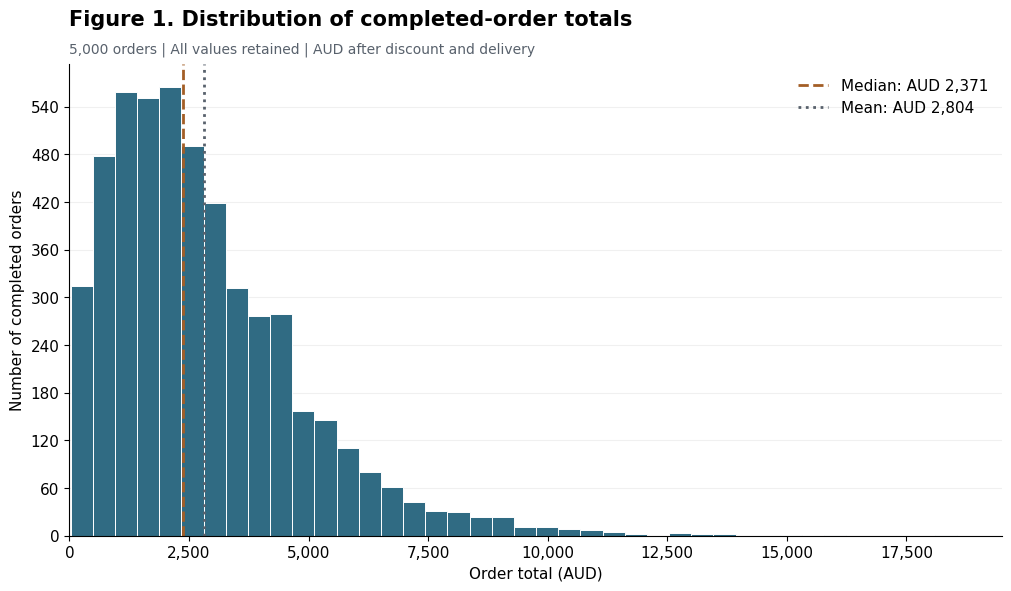

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.8), layout="constrained")

histogram_counts, _, _ = ax.hist(
    order_totals, bins=HISTOGRAM_BINS,
    color=PRIMARY_COLOUR, edgecolor="white", linewidth=0.7,
)
ax.axvline(
    median_order_total, color=SECONDARY_COLOUR, linestyle="--", linewidth=2,
    label=f"Median: AUD {median_order_total:,.0f}",
)
ax.axvline(
    mean_order_total, color=NEUTRAL_COLOUR, linestyle=":", linewidth=2,
    label=f"Mean: AUD {mean_order_total:,.0f}",
)
ax.set_title("Figure 1. Distribution of completed-order totals", loc="left", pad=28)
ax.text(
    0, 1.025, f"{order_count:,} orders | All values retained | AUD after discount and delivery",
    transform=ax.transAxes, fontsize=10, color=NEUTRAL_COLOUR,
)
ax.set_xlabel("Order total (AUD)")
ax.set_ylabel("Number of completed orders")
ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:,.0f}"))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.18)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")

record_eda_check(
    "EDA-FIG1-COUNT", "Histogram includes every analysed order",
    int(histogram_counts.sum()) == order_count,
    f"{int(histogram_counts.sum()):,} plotted of {order_count:,} orders",
)
fig.savefig(FIGURE_DIR / "Group018_Figure1_order_totals.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


In [7]:
display(Markdown(
    f"**Observation and decision:** Across {order_count:,} completed orders, the median total "
    f"is AUD {median_order_total:,.2f}, while the mean is AUD {mean_order_total:,.2f} "
    f"({mean_median_gap_percentage:.2f}% higher). The middle 50% lie between AUD "
    f"{lower_quartile:,.2f} and AUD {upper_quartile:,.2f}. There are {upper_tail_count:,} "
    f"orders ({upper_tail_percentage:.2f}%) above the upper 1.5-IQR fence of AUD "
    f"{upper_tail_fence:,.2f}. The median and quartiles are therefore reported alongside "
    f"the mean, and all large orders remain in the analysis.\n\n"
    "**Material limitation:** An order total combines basket quantity, item prices, "
    "discounts and delivery charges. It does not measure an individual customer's "
    "usual spending or profit. The IQR rule is a descriptive flag; it does not prove "
    "that an order is erroneous or fraudulent."
))


**Observation and decision:** Across 5,000 completed orders, the median total is AUD 2,371.01, while the mean is AUD 2,804.05 (18.26% higher). The middle 50% lie between AUD 1,333.65 and AUD 3,829.78. There are 150 orders (3.00%) above the upper 1.5-IQR fence of AUD 7,573.98. The median and quartiles are therefore reported alongside the mean, and all large orders remain in the analysis.

**Material limitation:** An order total combines basket quantity, item prices, discounts and delivery charges. It does not measure an individual customer's usual spending or profit. The IQR rule is a descriptive flag; it does not prove that an order is erroneous or fraudulent.

### Figure 2: Products generating the most gross item revenue

**Question:** Which products contribute the most gross item revenue, and how
much of the total do the leading products represent?  
**Category:** Bivariate product comparison.  
**Observation unit:** One product after aggregation from individual order items.  
**Denominator:** Revenue percentages use the sum of `line_revenue` across all
eligible order items, including products outside the top ten. Unit percentages
use the sum of `quantity` across those same items.  
**Tables and join keys:** `order_items` left joined to `products` on `product_id`,
validated as many items to one product. The joined table retains item grain
until product-level aggregation.  
**Chart choice:** A sorted horizontal bar chart allows ten product names and
revenue values to be read together. Revenue starts at zero.  
**Measure:** Gross item revenue in AUD, including GST, before coupon discounts
and excluding delivery charges. This is not profit or net revenue.


In [8]:
# Attach product labels without multiplying item rows.
product_details = products[["product_id", "product_name"]].copy()
item_row_count_before = len(order_items)
item_revenue_before = order_items["line_revenue"].sum()

items_with_products = order_items.merge(
    product_details,
    on="product_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

unmatched_product_rows = int(items_with_products["_merge"].ne("both").sum())
item_revenue_after = items_with_products["line_revenue"].sum()

record_eda_check(
    "EDA-JOIN-01", "Item-to-product join preserves item row count",
    len(items_with_products) == item_row_count_before,
    f"{item_row_count_before:,} rows before and {len(items_with_products):,} after",
)
record_eda_check(
    "EDA-JOIN-02", "Every item matches one product",
    unmatched_product_rows == 0,
    f"{unmatched_product_rows} unmatched product references",
)
record_eda_check(
    "EDA-JOIN-03", "Item-to-product join preserves gross item revenue",
    abs(item_revenue_before - item_revenue_after) <= CURRENCY_TOLERANCE,
    f"AUD {item_revenue_before:,.2f} before and AUD {item_revenue_after:,.2f} after",
)
display(pd.DataFrame(eda_check_rows[-3:]))


,check_id,description,status,observed
0,EDA-JOIN-01,Item-to-product join preserves item row count,PASS,"15,618 rows before and 15,618 after"
1,EDA-JOIN-02,Every item matches one product,PASS,0 unmatched product references
2,EDA-JOIN-03,Item-to-product join preserves gross item revenue,PASS,"AUD 15,457,463.98 before and AUD 15,457,463.98..."


In [9]:
# Aggregate only after checking the many-to-one join.
product_revenue = (
    items_with_products.groupby(["product_id", "product_name"], as_index=False)
    .agg(
        gross_item_revenue=("line_revenue", "sum"),
        units_sold=("quantity", "sum"),
        item_rows=("order_item_id", "size"),
    )
    .sort_values(["gross_item_revenue", "product_id"], ascending=[False, True])
    .reset_index(drop=True)
)

total_item_revenue = order_items["line_revenue"].sum()
total_units_sold = order_items["quantity"].sum()
sold_product_count = len(product_revenue)
product_revenue["revenue_share_percentage"] = (
    100 * product_revenue["gross_item_revenue"] / total_item_revenue
)

top_products = product_revenue.head(TOP_PRODUCT_COUNT).copy()
top_product_revenue = top_products["gross_item_revenue"].sum()
top_product_share_percentage = 100 * top_product_revenue / total_item_revenue
top_product_units = top_products["units_sold"].sum()
top_product_unit_share_percentage = 100 * top_product_units / total_units_sold
revenue_leader = product_revenue.iloc[0]
quantity_leader = product_revenue.sort_values(
    ["units_sold", "product_id"], ascending=[False, True]
).iloc[0]

record_eda_check(
    "EDA-AGG-01", "Product aggregation preserves the full revenue denominator",
    abs(product_revenue["gross_item_revenue"].sum() - total_item_revenue) <= CURRENCY_TOLERANCE,
    f"AUD {product_revenue['gross_item_revenue'].sum():,.2f} across {sold_product_count:,} sold products",
)
record_eda_check(
    "EDA-AGG-02", "Product aggregation preserves item and unit counts",
    product_revenue["item_rows"].sum() == len(order_items)
    and product_revenue["units_sold"].sum() == total_units_sold,
    f"{int(product_revenue['item_rows'].sum()):,} item rows and {int(total_units_sold):,} units",
)

display(top_products.round({"gross_item_revenue": 2, "revenue_share_percentage": 3}))
print(f"Revenue denominator: AUD {total_item_revenue:,.2f} across {len(order_items):,} items.")
print(f"Top {len(top_products)} products: {top_product_share_percentage:.2f}% of revenue.")
print(f"Top {len(top_products)} products: {int(top_product_units):,} of {int(total_units_sold):,} units "
      f"({top_product_unit_share_percentage:.2f}%).")

# Show both leaders because revenue and unit demand answer different questions.
leader_comparison = pd.DataFrame([
    {"comparison": "Highest gross item revenue", "product_id": revenue_leader["product_id"],
     "product_name": revenue_leader["product_name"], "units_sold": revenue_leader["units_sold"],
     "gross_item_revenue_AUD": revenue_leader["gross_item_revenue"]},
    {"comparison": "Highest unit sales", "product_id": quantity_leader["product_id"],
     "product_name": quantity_leader["product_name"], "units_sold": quantity_leader["units_sold"],
     "gross_item_revenue_AUD": quantity_leader["gross_item_revenue"]},
])
display(leader_comparison.round({"gross_item_revenue_AUD": 2}))


,product_id,product_name,gross_item_revenue,units_sold,item_rows,revenue_share_percentage
0,PRD0431,Candle Orbit 530,78883.00,35.0,29,0.510
1,PRD0804,Vela Core 903,65198.00,56.0,39,0.422
2,PRD0461,Candle Vista 560,64509.76,31.0,22,0.417
3,PRD0614,Vela Halo 713,64127.16,18.0,12,0.415
4,PRD0134,Vela Atlas 233,62433.18,18.0,13,0.404
5,PRD0504,Vela Spark 603,61403.20,16.0,11,0.397
6,PRD0174,Vela Core 273,58658.70,15.0,11,0.379
7,PRD0931,Candle Lumen 1030,58247.28,28.0,20,0.377
8,PRD0394,Vela Echo 493,55833.95,17.0,14,0.361
9,PRD0181,Candle Bloom 280,55270.08,18.0,9,0.358


Revenue denominator: AUD 15,457,463.98 across 15,618 items.
Top 10 products: 4.04% of revenue.
Top 10 products: 252 of 20,004 units (1.26%).


,comparison,product_id,product_name,units_sold,gross_item_revenue_AUD
0,Highest gross item revenue,PRD0431,Candle Orbit 530,35.0,78883.00
1,Highest unit sales,PRD0010,Vela Pulse 109,155.0,2475.35


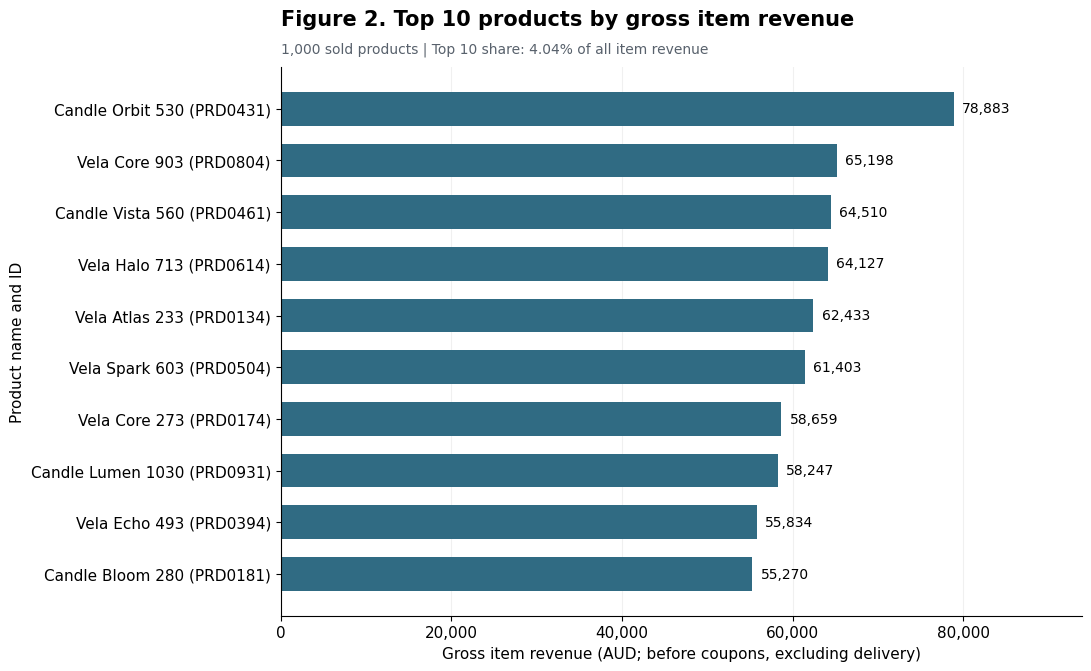

In [10]:
fig, ax = plt.subplots(figsize=(10.8, 6.6), layout="constrained")

product_labels = top_products["product_name"] + " (" + top_products["product_id"] + ")"
bars = ax.barh(product_labels, top_products["gross_item_revenue"], color=PRIMARY_COLOUR, height=0.65)
ax.invert_yaxis()
ax.bar_label(bars, labels=[f"{value:,.0f}" for value in top_products["gross_item_revenue"]], padding=6, fontsize=10)
ax.set_title(f"Figure 2. Top {len(top_products)} products by gross item revenue", loc="left", pad=30)
ax.text(
    0, 1.025,
    f"{sold_product_count:,} sold products | Top {len(top_products)} share: {top_product_share_percentage:.2f}% of all item revenue",
    transform=ax.transAxes, fontsize=10, color=NEUTRAL_COLOUR,
)
ax.set_xlabel("Gross item revenue (AUD; before coupons, excluding delivery)")
ax.set_ylabel("Product name and ID")
ax.set_xlim(0, top_products["gross_item_revenue"].max() * 1.19)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:,.0f}"))
ax.grid(axis="x", alpha=0.18)
ax.set_axisbelow(True)

fig.savefig(FIGURE_DIR / "Group018_Figure2_product_revenue.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


In [11]:
display(Markdown(
    f"**Observation and decision:** The checked join preserves all {len(order_items):,} item rows "
    f"and AUD {total_item_revenue:,.2f} in gross item revenue. The top {len(top_products)} of "
    f"{sold_product_count:,} sold products account for AUD {top_product_revenue:,.2f}, or "
    f"{top_product_share_percentage:.2f}% of that revenue. {revenue_leader['product_name']} "
    f"({revenue_leader['product_id']}) leads revenue with AUD {revenue_leader['gross_item_revenue']:,.2f} "
    f"from {int(revenue_leader['units_sold']):,} units. However, the unit-sales leader is "
    f"{quantity_leader['product_name']} ({quantity_leader['product_id']}), with "
    f"{int(quantity_leader['units_sold']):,} units and AUD {quantity_leader['gross_item_revenue']:,.2f}. "
    "Inventory quantities should therefore be considered alongside unit demand and the wider catalogue.\n\n"
    "**Material limitation:** Revenue combines selling price and quantity. High revenue does not "
    "establish high profit or high unit demand, and the extract does not measure stock availability "
    "or lost sales. The displayed leaders are selected from the observed period, so their ranks "
    "need not persist in a later period."
))


**Observation and decision:** The checked join preserves all 15,618 item rows and AUD 15,457,463.98 in gross item revenue. The top 10 of 1,000 sold products account for AUD 624,564.31, or 4.04% of that revenue. Candle Orbit 530 (PRD0431) leads revenue with AUD 78,883.00 from 35 units. However, the unit-sales leader is Vela Pulse 109 (PRD0010), with 155 units and AUD 2,475.35. Inventory quantities should therefore be considered alongside unit demand and the wider catalogue.

**Material limitation:** Revenue combines selling price and quantity. High revenue does not establish high profit or high unit demand, and the extract does not measure stock availability or lost sales. The displayed leaders are selected from the observed period, so their ranks need not persist in a later period.

### Figure 3: Weekly completed-order pattern

**Question:** How does completed-order workload vary between comparable
calendar weeks?  
**Category:** Temporal pattern.  
**Observation unit:** One Monday-to-Sunday calendar week; each order is counted once.  
**Denominator:** Weekly counts include orders placed in that week. The full-week
average uses only calendar weeks entirely within the extract's observed date
range. Counts for partial boundary weeks are displayed separately.  
**Tables and join keys:** `orders.order_timestamp` and `orders.order_id`; no join.  
**Chart choice:** A line chart preserves temporal ordering. Partial boundary
weeks use a separate marker and are not connected to the full-week line.  
**Coverage assumption:** Dates between the earliest and latest observed order
dates are treated as the extract's observation window. This is a calendar
coverage assumption, not independent proof of uninterrupted system capture.


In [12]:
# Parse the already-standardised timestamp only in an analysis copy.
order_times = orders[["order_id", "order_timestamp"]].copy()
order_times["order_timestamp"] = pd.to_datetime(
    order_times["order_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise",
)
record_eda_check(
    "EDA-TIME-01", "Every order has a usable timestamp",
    order_times["order_timestamp"].notna().all(),
    f"{int(order_times['order_timestamp'].notna().sum()):,} usable timestamps",
)

first_order_timestamp = order_times["order_timestamp"].min()
last_order_timestamp = order_times["order_timestamp"].max()
first_observed_date = first_order_timestamp.normalize()
last_observed_date = last_order_timestamp.normalize()
order_times["order_week"] = order_times["order_timestamp"].dt.to_period(WEEK_FREQUENCY)

# Include any zero-order calendar weeks inside the observed date range.
calendar_weeks = pd.period_range(
    start=first_observed_date, end=last_observed_date, freq=WEEK_FREQUENCY,
)
weekly_counts = (
    order_times.groupby("order_week")["order_id"].size()
    .reindex(calendar_weeks, fill_value=0)
)
weekly_orders = pd.DataFrame({
    "week_start": calendar_weeks.start_time,
    "week_end": calendar_weeks.end_time.normalize(),
    "order_count": weekly_counts.to_numpy(),
})

# Count calendar dates inside the observation window, not opening days.
covered_starts = weekly_orders["week_start"].clip(lower=first_observed_date)
covered_ends = weekly_orders["week_end"].clip(upper=last_observed_date)
weekly_orders["calendar_days_in_window"] = (covered_ends - covered_starts).dt.days + 1
weekly_orders["complete_calendar_week"] = weekly_orders["calendar_days_in_window"].eq(7)

complete_weeks = weekly_orders.loc[weekly_orders["complete_calendar_week"]].copy()
partial_weeks = weekly_orders.loc[~weekly_orders["complete_calendar_week"]].copy()

record_eda_check(
    "EDA-TIME-02", "Weekly aggregation counts every order exactly once",
    int(weekly_orders["order_count"].sum()) == len(orders),
    f"{int(weekly_orders['order_count'].sum()):,} weekly orders from {len(orders):,} order rows",
)
record_eda_check(
    "EDA-TIME-03", "At least one complete calendar week is available",
    len(complete_weeks) > 0,
    f"{len(complete_weeks)} complete and {len(partial_weeks)} partial calendar weeks",
)

full_week_mean = complete_weeks["order_count"].mean()
maximum_week_count = int(complete_weeks["order_count"].max())
minimum_week_count = int(complete_weeks["order_count"].min())
busiest_weeks = complete_weeks.loc[complete_weeks["order_count"].eq(maximum_week_count)]
quietest_weeks = complete_weeks.loc[complete_weeks["order_count"].eq(minimum_week_count)]
busiest_week = busiest_weeks.iloc[0]
quietest_week = quietest_weeks.iloc[0]

print(f"Observed timestamps: {first_order_timestamp} to {last_order_timestamp}.")
print(f"Full-week denominator: {len(complete_weeks)} weeks and "
      f"{int(complete_weeks['order_count'].sum()):,} orders.")
print(f"Mean full-week count: {full_week_mean:.2f} orders.")
print("Highest full-week count (all ties shown):")
display(busiest_weeks)
print("Lowest full-week count (all ties shown):")
display(quietest_weeks)
print("Partial boundary weeks excluded from the mean and extrema:")
display(partial_weeks)


Observed timestamps: 2018-01-01 08:05:00 to 2018-12-31 20:36:00.
Full-week denominator: 52 weeks and 4,982 orders.
Mean full-week count: 95.81 orders.
Highest full-week count (all ties shown):


,week_start,week_end,order_count,calendar_days_in_window,complete_calendar_week
30,2018-07-30,2018-08-05,115,7,True


Lowest full-week count (all ties shown):


,week_start,week_end,order_count,calendar_days_in_window,complete_calendar_week
41,2018-10-15,2018-10-21,75,7,True


Partial boundary weeks excluded from the mean and extrema:


,week_start,week_end,order_count,calendar_days_in_window,complete_calendar_week
52,2018-12-31,2019-01-06,18,1,False


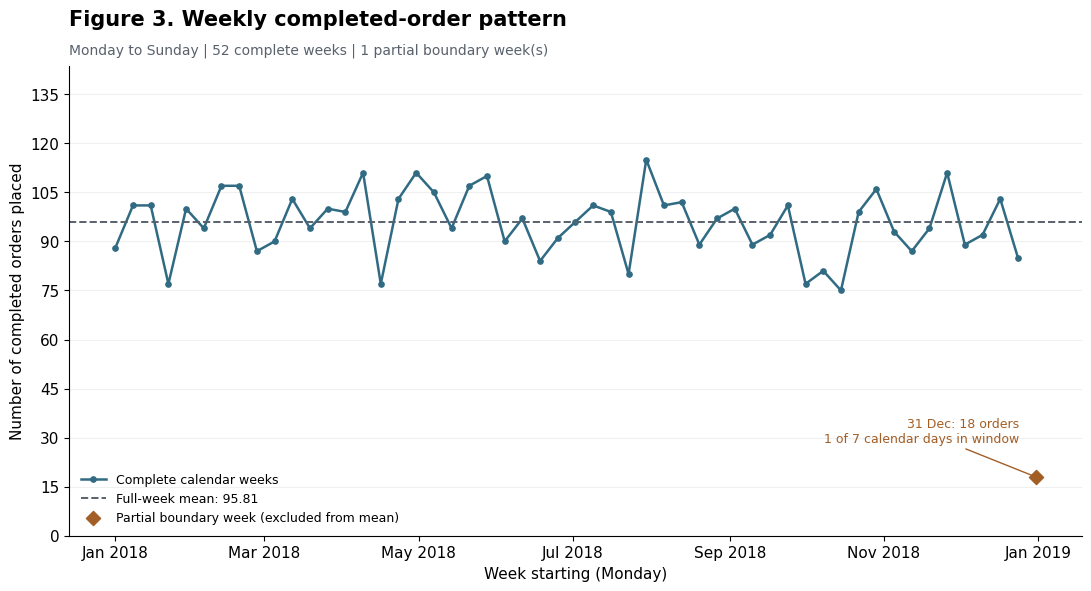

In [13]:
fig, ax = plt.subplots(figsize=(10.8, 5.8), layout="constrained")

# Leave partial weeks out of the line so they cannot imply a sudden decline.
full_week_line = weekly_orders["order_count"].where(weekly_orders["complete_calendar_week"])
ax.plot(
    weekly_orders["week_start"], full_week_line,
    color=PRIMARY_COLOUR, linewidth=1.8, marker="o", markersize=3.8,
    label="Complete calendar weeks",
)
ax.axhline(
    full_week_mean, color=NEUTRAL_COLOUR, linestyle="--", linewidth=1.4,
    label=f"Full-week mean: {full_week_mean:.2f}",
)

if not partial_weeks.empty:
    ax.scatter(
        partial_weeks["week_start"], partial_weeks["order_count"],
        color=SECONDARY_COLOUR, marker="D", s=52, zorder=4,
        label="Partial boundary week (excluded from mean)",
    )
    for row in partial_weeks.itertuples(index=False):
        ax.annotate(
            f"{row.week_start:%d %b}: {row.order_count} orders\n"
            f"{row.calendar_days_in_window} of 7 calendar days in window",
            xy=(row.week_start, row.order_count), xytext=(-12, 25),
            textcoords="offset points", ha="right", fontsize=9,
            color=SECONDARY_COLOUR,
            arrowprops={"arrowstyle": "-", "color": SECONDARY_COLOUR},
        )

ax.set_title("Figure 3. Weekly completed-order pattern", loc="left", pad=29)
ax.text(
    0, 1.025,
    f"Monday to Sunday | {len(complete_weeks)} complete weeks | {len(partial_weeks)} partial boundary week(s)",
    transform=ax.transAxes, fontsize=10, color=NEUTRAL_COLOUR,
)
ax.set_xlabel("Week starting (Monday)")
ax.set_ylabel("Number of completed orders placed")
ax.set_ylim(0, maximum_week_count * 1.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.18)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower left", fontsize=9)

fig.savefig(FIGURE_DIR / "Group018_Figure3_weekly_orders.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


In [14]:
partial_week_descriptions = []
for row in partial_weeks.itertuples(index=False):
    partial_week_descriptions.append(
        f"the week starting {row.week_start:%d %B %Y} contains {row.order_count:,} orders "
        f"and only {row.calendar_days_in_window} of 7 calendar dates within the observed window"
    )
partial_week_description = "; ".join(partial_week_descriptions) or "there are no partial boundary weeks"

display(Markdown(
    f"**Observation and decision:** There are {int(complete_weeks['order_count'].sum()):,} "
    f"orders across {len(complete_weeks)} complete calendar weeks, averaging "
    f"{full_week_mean:.2f} orders per week. Full-week counts range from {minimum_week_count} "
    f"to {maximum_week_count}. A highest-count week is {busiest_week['week_start']:%d %B} "
    f"to {busiest_week['week_end']:%d %B %Y}; a lowest-count week is "
    f"{quietest_week['week_start']:%d %B} to {quietest_week['week_end']:%d %B %Y}. "
    f"For the boundary comparison, {partial_week_description}. Partial weeks are therefore "
    "excluded from the mean and the highest/lowest full-week comparisons.\n\n"
    "**Material limitation:** Calendar coverage is inferred from the observed date range; "
    "unrecorded transactions or system outages cannot be ruled out. A single year does not "
    "establish recurring annual seasonality, and the plot cannot show that promotions caused "
    "weekly changes. Completed-order workload also excludes abandoned or cancelled purchases."
))


**Observation and decision:** There are 4,982 orders across 52 complete calendar weeks, averaging 95.81 orders per week. Full-week counts range from 75 to 115. A highest-count week is 30 July to 05 August 2018; a lowest-count week is 15 October to 21 October 2018. For the boundary comparison, the week starting 31 December 2018 contains 18 orders and only 1 of 7 calendar dates within the observed window. Partial weeks are therefore excluded from the mean and the highest/lowest full-week comparisons.

**Material limitation:** Calendar coverage is inferred from the observed date range; unrecorded transactions or system outages cannot be ruled out. A single year does not establish recurring annual seasonality, and the plot cannot show that promotions caused weekly changes. Completed-order workload also excludes abandoned or cancelled purchases.

### Figures 4-6

| Figure | Analysis | Tables |
|---|---|---|
| 4: Review/text behaviour | Review language counts and percentages | `product_reviews.language_code` |
| 5: Operational performance | Late-delivery percentage by order-value group | Join `deliveries` and `orders` on `order_id`; use `delay_days > 0` and report each group's delivery count. |
| 6: Multivariate relationship | Review length by rating, split by non-Latin-script status | `product_reviews.rating`, `review_length_chars` and `contains_non_latin_script`; report group sizes and any sentinel exclusions. |

These analyses remain to be added. Check row counts and totals when joining tables.


## 3. Evidence-based findings


In [15]:
display(Markdown(
    f"1. **Typical order size requires more than the average (Figure 1).** Across "
    f"{order_count:,} completed orders, the mean of AUD {mean_order_total:,.2f} exceeds "
    f"the median of AUD {median_order_total:,.2f} by {mean_median_gap_percentage:.2f}%. "
    f"The middle half lie between AUD {lower_quartile:,.2f} and AUD {upper_quartile:,.2f}. "
    "This matters when describing typical basket value. Different prices and item quantities "
    "could explain the gap, so report median and quartiles alongside the mean and inspect "
    "basket composition before attributing it to customer habits.\n\n"
    f"2. **Large orders warrant investigation, not automatic removal (Figure 1).** "
    f"There are {upper_tail_count:,} of {order_count:,} orders ({upper_tail_percentage:.2f}%) "
    f"above the upper 1.5-IQR fence of AUD {upper_tail_fence:,.2f}; the maximum is "
    f"AUD {order_totals.max():,.2f}. These orders may require different fulfilment attention, "
    "but expensive products or larger legitimate baskets are alternative explanations. "
    "Retain them and review their item composition before treating them as errors or fraud.\n\n"
    f"3. **The revenue leaders represent a small share of the catalogue total (Figure 2).** "
    f"The leading {len(top_products)} of {sold_product_count:,} sold products generate AUD "
    f"{top_product_revenue:,.2f}, or {top_product_share_percentage:.2f}% of AUD "
    f"{total_item_revenue:,.2f} gross item revenue across {len(order_items):,} items. "
    f"The remaining products account for {100 - top_product_share_percentage:.2f}%. "
    "This limits the usefulness of concentrating inventory decisions on the displayed top ten. "
    "Availability and product age could affect the ranking; inspect the wider catalogue and "
    "stock history before changing purchasing priorities.\n\n"
    f"4. **Revenue rank and unit-demand rank differ (Figure 2 and its leader-comparison table).** "
    f"The revenue leader, {revenue_leader['product_name']} ({revenue_leader['product_id']}), "
    f"contributes AUD {revenue_leader['gross_item_revenue']:,.2f} from "
    f"{int(revenue_leader['units_sold']):,} units. The quantity leader, "
    f"{quantity_leader['product_name']} ({quantity_leader['product_id']}), sells "
    f"{int(quantity_leader['units_sold']):,} units for AUD {quantity_leader['gross_item_revenue']:,.2f}. "
    f"The comparison covers {sold_product_count:,} sold products and {int(total_units_sold):,} total units. "
    "Different selling prices help explain the difference, while stock availability remains unknown. "
    "Use unit demand and replenishment information alongside revenue when planning quantities.\n\n"
    f"5. **Comparable weekly workload varies, and boundary weeks need separate treatment (Figure 3).** "
    f"The {len(complete_weeks)} complete calendar weeks contain "
    f"{int(complete_weeks['order_count'].sum()):,} orders, with counts from {minimum_week_count} "
    f"to {maximum_week_count} and a mean of {full_week_mean:.2f}. In contrast, "
    f"{partial_week_description}. This distinction matters for staffing comparisons. "
    "Random variation or incomplete capture could contribute to the changes; use full-week "
    "comparisons and seek more years and operating-calendar evidence before claiming seasonality."
))


1. **Typical order size requires more than the average (Figure 1).** Across 5,000 completed orders, the mean of AUD 2,804.05 exceeds the median of AUD 2,371.01 by 18.26%. The middle half lie between AUD 1,333.65 and AUD 3,829.78. This matters when describing typical basket value. Different prices and item quantities could explain the gap, so report median and quartiles alongside the mean and inspect basket composition before attributing it to customer habits.

2. **Large orders warrant investigation, not automatic removal (Figure 1).** There are 150 of 5,000 orders (3.00%) above the upper 1.5-IQR fence of AUD 7,573.98; the maximum is AUD 18,565.28. These orders may require different fulfilment attention, but expensive products or larger legitimate baskets are alternative explanations. Retain them and review their item composition before treating them as errors or fraud.

3. **The revenue leaders represent a small share of the catalogue total (Figure 2).** The leading 10 of 1,000 sold products generate AUD 624,564.31, or 4.04% of AUD 15,457,463.98 gross item revenue across 15,618 items. The remaining products account for 95.96%. This limits the usefulness of concentrating inventory decisions on the displayed top ten. Availability and product age could affect the ranking; inspect the wider catalogue and stock history before changing purchasing priorities.

4. **Revenue rank and unit-demand rank differ (Figure 2 and its leader-comparison table).** The revenue leader, Candle Orbit 530 (PRD0431), contributes AUD 78,883.00 from 35 units. The quantity leader, Vela Pulse 109 (PRD0010), sells 155 units for AUD 2,475.35. The comparison covers 1,000 sold products and 20,004 total units. Different selling prices help explain the difference, while stock availability remains unknown. Use unit demand and replenishment information alongside revenue when planning quantities.

5. **Comparable weekly workload varies, and boundary weeks need separate treatment (Figure 3).** The 52 complete calendar weeks contain 4,982 orders, with counts from 75 to 115 and a mean of 95.81. In contrast, the week starting 31 December 2018 contains 18 orders and only 1 of 7 calendar dates within the observed window. This distinction matters for staffing comparisons. Random variation or incomplete capture could contribute to the changes; use full-week comparisons and seek more years and operating-calendar evidence before claiming seasonality.

## 4. Future machine-learning questions


In [16]:
# Count customers with repeat purchases and subsequent orders.
customer_order_counts = orders.groupby("customer_id")["order_id"].size()
repeat_customer_count = int(customer_order_counts.gt(1).sum())
subsequent_order_count = int((customer_order_counts - 1).clip(lower=0).sum())

display(Markdown(
    "### MLQ-1: Can prior purchase history identify a high-value next completed order?\n\n"
    "| Element | Proposed design |\n|---|---|\n"
    f"| EDA evidence | Figure 1: mean AUD {mean_order_total:,.2f}, median AUD {median_order_total:,.2f}. "
    f"The orders table contains {repeat_customer_count} customers with repeat purchases and "
    f"{subsequent_order_count:,} subsequent orders. |\n"
    "| Business decision | Prioritise optional customer-service preparation after a purchase. |\n"
    "| Problem type and analysis unit | Classification; one customer history cutoff after a completed purchase. |\n"
    "| Target | Whether the next observed completed-order total exceeds the training-period 90th percentile. "
    "Fix the threshold within each training window. |\n"
    "| Decision-time predictors | Earlier order totals, purchase frequency, basket quantities, channels and time gaps, "
    "all observed by the cutoff. |\n"
    "| Validation split and metric | Chronological evaluation at prediction cutoffs. Training outcomes must already "
    "be observed before validation starts. Use PR-AUC and calibration. |\n"
    "| Leakage, fairness or deployment risk | Exclude the target purchase's totals, basket and later activity. "
    "History features must use only earlier records. This predicts value conditional on returning, "
    "not return probability or promotion effectiveness; assess errors across historical customer groups. |"
))


### MLQ-1: Can prior purchase history identify a high-value next completed order?

| Element | Proposed design |
|---|---|
| EDA evidence | Figure 1: mean AUD 2,804.05, median AUD 2,371.01. The orders table contains 499 customers with repeat purchases and 4,500 subsequent orders. |
| Business decision | Prioritise optional customer-service preparation after a purchase. |
| Problem type and analysis unit | Classification; one customer history cutoff after a completed purchase. |
| Target | Whether the next observed completed-order total exceeds the training-period 90th percentile. Fix the threshold within each training window. |
| Decision-time predictors | Earlier order totals, purchase frequency, basket quantities, channels and time gaps, all observed by the cutoff. |
| Validation split and metric | Chronological evaluation at prediction cutoffs. Training outcomes must already be observed before validation starts. Use PR-AUC and calibration. |
| Leakage, fairness or deployment risk | Exclude the target purchase's totals, basket and later activity. History features must use only earlier records. This predicts value conditional on returning, not return probability or promotion effectiveness; assess errors across historical customer groups. |

In [17]:
display(Markdown(
    "### MLQ-2: Can earlier weekly counts predict next week's completed-order workload?\n\n"
    "| Element | Proposed design |\n|---|---|\n"
    f"| EDA evidence | Figure 3: {len(complete_weeks)} complete weeks, "
    f"{minimum_week_count}-{maximum_week_count} orders per week, mean {full_week_mean:.2f}. |\n"
    "| Business decision | Support provisional weekly staffing and fulfilment capacity planning. |\n"
    "| Problem type and analysis unit | Forecasting; one Monday-to-Sunday calendar week. |\n"
    "| Target | Next complete week's number of completed orders placed. |\n"
    "| Decision-time predictors | Lagged weekly counts, shifted historical rolling averages, and calendar "
    "fields known before the target week. |\n"
    "| Validation split and metric | Expanding-window one-week-ahead evaluation, holding out the latest complete weeks. "
    "Use MAE and compare with a previous-week or historical-mean baseline. |\n"
    "| Leakage, fairness or deployment risk | Exclude partial boundary weeks; construct lags before target rows "
    "and fit transformations inside each training window. Verify completed-status outcomes are available by "
    "each forecast cutoff; this historical extract lacks a status-change log. One year limits annual-seasonality "
    "claims, and staffing demand may also include cancelled orders. |"
))


### MLQ-2: Can earlier weekly counts predict next week's completed-order workload?

| Element | Proposed design |
|---|---|
| EDA evidence | Figure 3: 52 complete weeks, 75-115 orders per week, mean 95.81. |
| Business decision | Support provisional weekly staffing and fulfilment capacity planning. |
| Problem type and analysis unit | Forecasting; one Monday-to-Sunday calendar week. |
| Target | Next complete week's number of completed orders placed. |
| Decision-time predictors | Lagged weekly counts, shifted historical rolling averages, and calendar fields known before the target week. |
| Validation split and metric | Expanding-window one-week-ahead evaluation, holding out the latest complete weeks. Use MAE and compare with a previous-week or historical-mean baseline. |
| Leakage, fairness or deployment risk | Exclude partial boundary weeks; construct lags before target rows and fit transformations inside each training window. Verify completed-status outcomes are available by each forecast cutoff; this historical extract lacks a status-change log. One year limits annual-seasonality claims, and staffing demand may also include cancelled orders. |

## 5. Limitations and conclusion

This analysis describes completed purchases in one allocated historical
extract. It cannot measure abandoned purchases, cancelled orders, lost demand,
stock availability or the causal effect of marketing activity. Customers may
contribute several orders, so the order-level observations do not represent
independent people. Product revenue is measured before coupons and excludes
delivery charges; it must not be described as profit or compared directly with
order totals as though both measures have the same definition.

Weekly comparisons separate partial boundary weeks, but calendar coverage is
inferred from the observed dates. Recurring annual seasonality cannot be
established from this one-year extract. Proposed ML questions require careful
decision-time feature construction and verification of outcome availability.

Report order value using the median and spread, consider unit demand alongside
product revenue, and compare workload over equivalent time windows.


## 6. Reproducibility checks

Run **Restart and Run All** from the repository root. Check that the input CSVs
remain unchanged and that all three chart files exist.


In [18]:
for table_name, original_hash in input_file_hashes.items():
    file_path = OUTPUT_DIR / f"{GROUP_ID}_{table_name}_standardised.csv"
    current_hash = hashlib.sha256(file_path.read_bytes()).hexdigest()
    record_eda_check(
        f"EDA-INPUT-UNCHANGED-{table_name}", "Source CSV is unchanged after EDA",
        current_hash == original_hash, f"SHA-256 unchanged: {current_hash == original_hash}",
    )

figure_filenames = [
    "Group018_Figure1_order_totals.png",
    "Group018_Figure2_product_revenue.png",
    "Group018_Figure3_weekly_orders.png",
]
for filename in figure_filenames:
    figure_path = FIGURE_DIR / filename
    record_eda_check(
        f"EDA-EXPORT-{filename}", "Assessed figure image exists and is non-empty",
        figure_path.exists() and figure_path.stat().st_size > 0,
        str(figure_path),
    )

eda_register = pd.DataFrame(eda_check_rows)
display(eda_register)
print("Total EDA checks:", len(eda_register),
      "| PASS:", int(eda_register["status"].eq("PASS").sum()),
      "| FAIL:", int(eda_register["status"].eq("FAIL").sum()))


,check_id,description,status,observed
0,EDA-PK-orders,"Non-empty table with complete, unique primary ...",PASS,"5,000 rows; 0 missing and 0 duplicate keys"
1,EDA-PK-order_items,"Non-empty table with complete, unique primary ...",PASS,"15,618 rows; 0 missing and 0 duplicate keys"
2,EDA-PK-customers,"Non-empty table with complete, unique primary ...",PASS,500 rows; 0 missing and 0 duplicate keys
3,EDA-PK-deliveries,"Non-empty table with complete, unique primary ...",PASS,"5,000 rows; 0 missing and 0 duplicate keys"
4,EDA-PK-products,"Non-empty table with complete, unique primary ...",PASS,"1,000 rows; 0 missing and 0 duplicate keys"
5,EDA-PK-product_reviews,"Non-empty table with complete, unique primary ...",PASS,"7,000 rows; 0 missing and 0 duplicate keys"
6,EDA-SCOPE-01,All analysed orders are completed AUD orders,PASS,Statuses: {'Completed': 5000}; currencies: {'A...
7,EDA-NUMERIC-orders-order_total,Finite positive numeric analysis field,PASS,"5,000 values; dtype float64"
8,EDA-NUMERIC-order_items-line_revenue,Finite positive numeric analysis field,PASS,"15,618 values; dtype float64"
9,EDA-NUMERIC-order_items-quantity,Finite positive numeric analysis field,PASS,"15,618 values; dtype float64"


Total EDA checks: 29 | PASS: 29 | FAIL: 0


## References

- Monash University Malaysia. (2026). *FIT5196-S2-2026 Group Assessment,
  Stage 1 specification*. Tasks 5-6 and EDA report requirements.
- Monash University Malaysia. (2026). *Group018 allocated historical data package:
  public_data_dictionary.csv, README.md and A1_EDA_template.ipynb*.
- Group018. (2026). *Group018_solution.ipynb*,
  *Group018_source_to_target_mapping.csv* and *TASK5_HANDOFF.md*. Existing team
  transformation, validation and handoff records.
- Group018. (2026). *Six standardised CSVs in outputs/*. Direct inputs for every
  plotted value and reported statistic in this notebook.
